# Mineria de datos - Clase 5
### Alumno: Enzo Melián

Ejercicio Integrador

Supongamos que trabajamos en una empresa de análisis financiero y tenemos un dataset con información de clientes bancarios. Nuestro
objetivo es preparar los datos para un modelo de predicción de solvencia financiera.

In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

# Crear DataFrame
df = pd.DataFrame({
"Cliente":
 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
"Edad":
 [25, 40, 35, 50, 30, 45, 38, 29, 90, 85, None],
"Ingresos":
 [50000, 60000, 70000, 80000, 45000, 85000, 72000, 48000, 150000, 160000, None],
"Historial_Pagos":
 ["Bueno", "Regular", "Malo", "Bueno", "Regular", "Malo", "Bueno", "Regular", "Bueno", "Bueno", "Regular"],
"Categoría":
 ["A", "B", "C", "A", "B", "C", "A", "B", "A", "C", "B"]
})

df

,Cliente,Edad,Ingresos,Historial_Pagos,Categoría
0,1,25.0,50000.0,Bueno,A
1,2,40.0,60000.0,Regular,B
2,3,35.0,70000.0,Malo,C
3,4,50.0,80000.0,Bueno,A
4,5,30.0,45000.0,Regular,B
5,6,45.0,85000.0,Malo,C
6,7,38.0,72000.0,Bueno,A
7,8,29.0,48000.0,Regular,B
8,9,90.0,150000.0,Bueno,A
9,10,85.0,160000.0,Bueno,C


In [28]:
print(df.count())

Cliente            11
Edad               10
Ingresos           10
Historial_Pagos    11
Categoría          11
dtype: int64


#### 1. Limpieza de Datos

Identificar y manejar valores nulos en Edad o Ingresos.

In [29]:
#Manejo de valores nulos en Edad
df.fillna(df.median(numeric_only=True), inplace=True)
df

,Cliente,Edad,Ingresos,Historial_Pagos,Categoría
0,1,25.0,50000.0,Bueno,A
1,2,40.0,60000.0,Regular,B
2,3,35.0,70000.0,Malo,C
3,4,50.0,80000.0,Bueno,A
4,5,30.0,45000.0,Regular,B
5,6,45.0,85000.0,Malo,C
6,7,38.0,72000.0,Bueno,A
7,8,29.0,48000.0,Regular,B
8,9,90.0,150000.0,Bueno,A
9,10,85.0,160000.0,Bueno,C


Detectar outliers en Ingresos usando el método IQR y decidir si eliminarlos o transformarlos.

In [30]:
#Detectar outliers en Ingresos usando el método IQR y decidir si eliminarlos o transformarlos.
Q1 = df["Ingresos"].quantile(0.25)
Q3 = df["Ingresos"].quantile(0.75)
IQR = Q3 - Q1
df_cleaned = df[(df["Ingresos"] >= Q1 - 1.5*IQR) & (df["Ingresos"] <= Q3 + 1.5*IQR)]

df_cleaned

,Cliente,Edad,Ingresos,Historial_Pagos,Categoría
0,1,25.0,50000.0,Bueno,A
1,2,40.0,60000.0,Regular,B
2,3,35.0,70000.0,Malo,C
3,4,50.0,80000.0,Bueno,A
4,5,30.0,45000.0,Regular,B
5,6,45.0,85000.0,Malo,C
6,7,38.0,72000.0,Bueno,A
7,8,29.0,48000.0,Regular,B
10,11,39.0,71000.0,Regular,B


In [31]:
print(df_cleaned.count())

Cliente            9
Edad               9
Ingresos           9
Historial_Pagos    9
Categoría          9
dtype: int64


#### 2. Transformación de Datos Numéricos

Normalizar Ingresos usando Min-Max Scaling

In [32]:
scaler_minmax = MinMaxScaler()
df_cleaned["Ingresos_Normalizado"] = scaler_minmax.fit_transform(df_cleaned[["Ingresos"]])
df_cleaned

/tmp/ipykernel_11120/1665161349.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["Ingresos_Normalizado"] = scaler_minmax.fit_transform(df_cleaned[["Ingresos"]])


,Cliente,Edad,Ingresos,Historial_Pagos,Categoría,Ingresos_Normalizado
0,1,25.0,50000.0,Bueno,A,0.125
1,2,40.0,60000.0,Regular,B,0.375
2,3,35.0,70000.0,Malo,C,0.625
3,4,50.0,80000.0,Bueno,A,0.875
4,5,30.0,45000.0,Regular,B,0.000
5,6,45.0,85000.0,Malo,C,1.000
6,7,38.0,72000.0,Bueno,A,0.675
7,8,29.0,48000.0,Regular,B,0.075
10,11,39.0,71000.0,Regular,B,0.650


Estandarizar Edad con Z-score Scaling

In [33]:
scaler_std = StandardScaler()
df_cleaned["Edad_Estandarizada"] = scaler_std.fit_transform(df_cleaned[["Edad"]])
df_cleaned

/tmp/ipykernel_11120/458580773.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["Edad_Estandarizada"] = scaler_std.fit_transform(df_cleaned[["Edad"]])


,Cliente,Edad,Ingresos,Historial_Pagos,Categoría,Ingresos_Normalizado,Edad_Estandarizada
0,1,25.0,50000.0,Bueno,A,0.125,-1.568349
1,2,40.0,60000.0,Regular,B,0.375,0.429077
2,3,35.0,70000.0,Malo,C,0.625,-0.236732
3,4,50.0,80000.0,Bueno,A,0.875,1.760694
4,5,30.0,45000.0,Regular,B,0.000,-0.902541
5,6,45.0,85000.0,Malo,C,1.000,1.094885
6,7,38.0,72000.0,Bueno,A,0.675,0.162753
7,8,29.0,48000.0,Regular,B,0.075,-1.035702
10,11,39.0,71000.0,Regular,B,0.650,0.295915


Gráficos de Ingresos: Antes (df original con nulos imputados) vs Después (df_cleaned con outliers eliminados y normalizado)

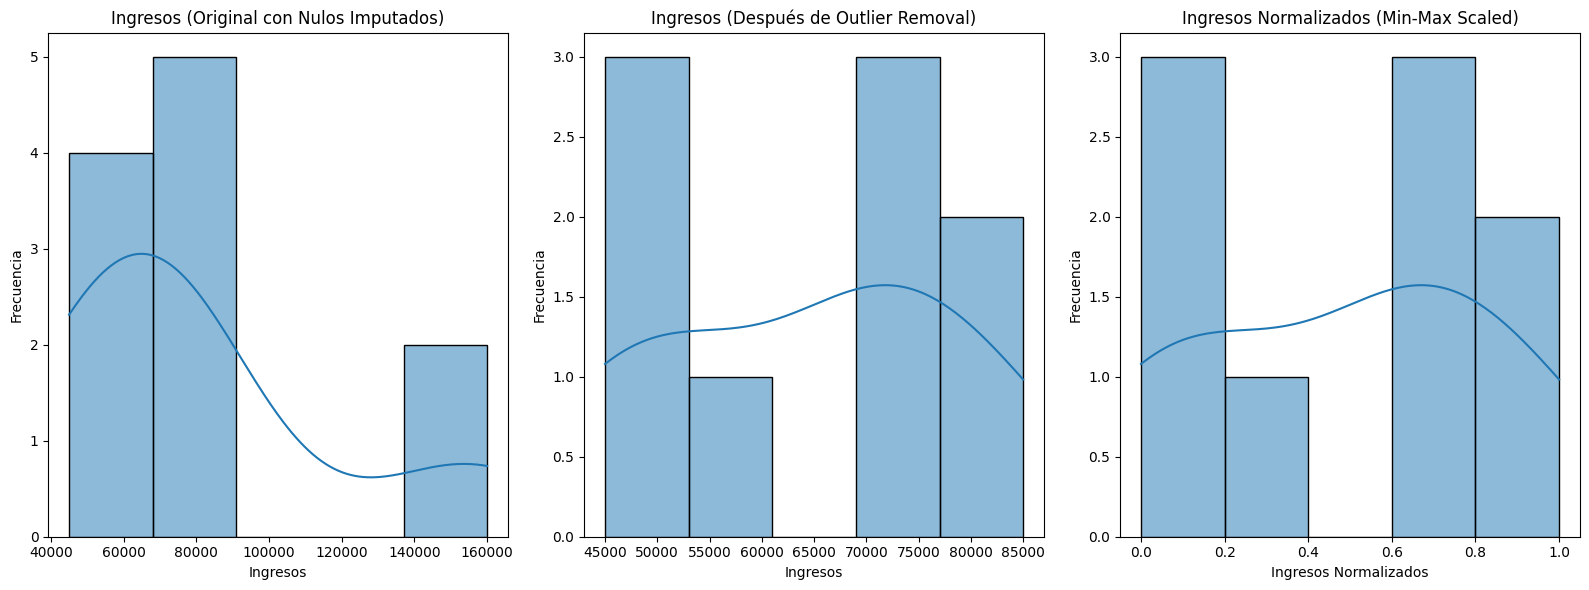

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráficos de Ingresos: Antes (df original con nulos imputados) vs Después (df_cleaned con outliers eliminados y normalizado)
plt.figure(figsize=(16, 6))

plt.subplot(1, 3, 1)
sns.histplot(df['Ingresos'], kde=True)
plt.title('Ingresos (Original con Nulos Imputados)')
plt.xlabel('Ingresos')
plt.ylabel('Frecuencia')

plt.subplot(1, 3, 2)
sns.histplot(df_cleaned['Ingresos'], kde=True)
plt.title('Ingresos (Después de Outlier Removal)')
plt.xlabel('Ingresos')
plt.ylabel('Frecuencia')

plt.subplot(1, 3, 3)
sns.histplot(df_cleaned['Ingresos_Normalizado'], kde=True)
plt.title('Ingresos Normalizados (Min-Max Scaled)')
plt.xlabel('Ingresos Normalizados')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Gráficos de Edad: Antes (df original con nulos imputados) vs Después (df_cleaned estandarizado)

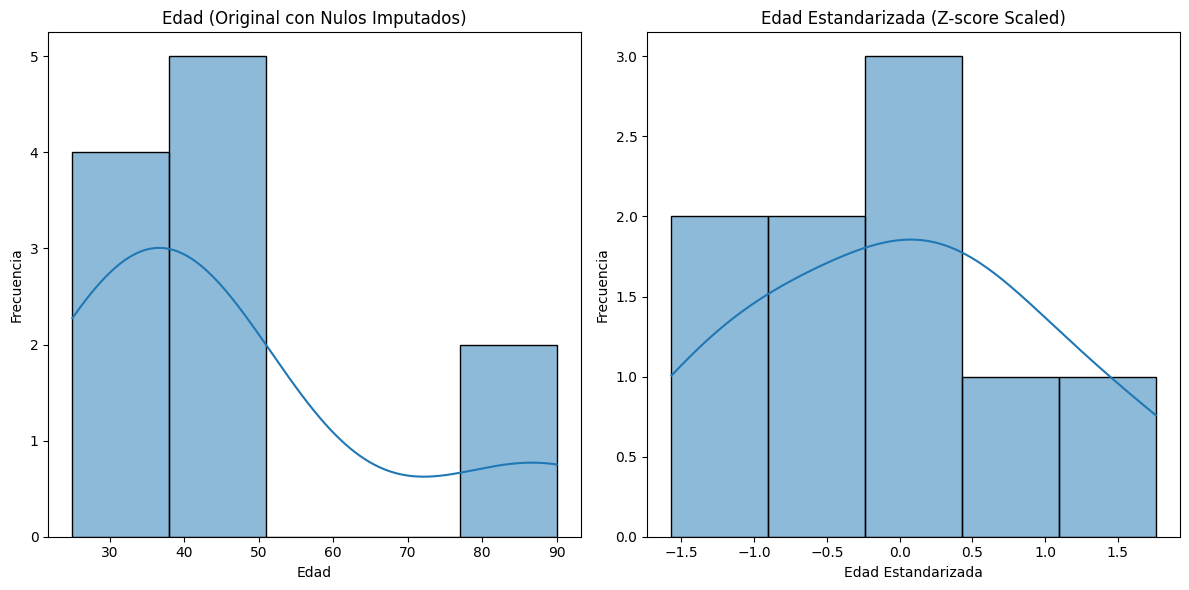

In [36]:
# Gráficos de Edad: Antes (df original con nulos imputados) vs Después (df_cleaned estandarizado)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Edad'], kde=True)
plt.title('Edad (Original con Nulos Imputados)')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df_cleaned['Edad_Estandarizada'], kde=True)
plt.title('Edad Estandarizada (Z-score Scaled)')
plt.xlabel('Edad Estandarizada')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

#### 3. Transformación de Datos Categóricos

Aplicar One-Hot Encoding a la columna Historial de Pagos

In [34]:
df_cleaned = pd.get_dummies(df_cleaned, columns=["Historial_Pagos"], prefix="Historial")
le = LabelEncoder()
df_cleaned["Categoría_Label"] = le.fit_transform(df_cleaned["Categoría"])
df_cleaned

,Cliente,Edad,Ingresos,Categoría,Ingresos_Normalizado,Edad_Estandarizada,Historial_Bueno,Historial_Malo,Historial_Regular,Categoría_Label
0,1,25.0,50000.0,A,0.125,-1.568349,True,False,False,0
1,2,40.0,60000.0,B,0.375,0.429077,False,False,True,1
2,3,35.0,70000.0,C,0.625,-0.236732,False,True,False,2
3,4,50.0,80000.0,A,0.875,1.760694,True,False,False,0
4,5,30.0,45000.0,B,0.000,-0.902541,False,False,True,1
5,6,45.0,85000.0,C,1.000,1.094885,False,True,False,2
6,7,38.0,72000.0,A,0.675,0.162753,True,False,False,0
7,8,29.0,48000.0,B,0.075,-1.035702,False,False,True,1
10,11,39.0,71000.0,B,0.650,0.295915,False,False,True,1


Aplicar Label Encoding a la columna Categoría

#### 4. Interacción con una Herramienta de IA (LLM)

Consulta: ¿Qué métodos avanzados de imputación de datos recomiendas para conjuntos de datos con muchas variables
numéricas y categóricas?

Su respuesta resumidamente fue:

Para conjuntos de datos con muchas variables numéricas y categóricas, donde la imputación simple (como la mediana o la moda) podría no ser suficiente, recomiendo considerar estos métodos más avanzados:

1. Métodos Avanzados para Variables Numéricas:

- Imputación por Modelos Predictivos (MICE - Multiple Imputation by Chained Equations / Iterative Imputer):
En lugar de imputar un valor fijo, MICE
modela cada característica con valores faltantes en función de otras características en el conjunto de datos. Realiza múltiples imputaciones, creando varias versiones del conjunto de datos completo, y luego combina los resultados.
  
- Imputación K-NN (K-Nearest Neighbors Imputer): Imputa los valores faltantes utilizando los valores de las k muestras más cercanas en el conjunto de datos. Para un valor numérico faltante, puede usar la media o la mediana de sus vecinos.
Ventajas: Considera la estructura de los datos y las relaciones entre instancias. No asume una distribución específica.

- Imputación con Modelos de Aprendizaje Automático (e.g., Random Forest Imputation): Utiliza un algoritmo de machine learning (como Random Forest) para predecir los valores faltantes. Entrena un modelo con las variables completas para predecir la variable con datos faltantes.


2. Métodos Avanzados para Variables Categóricas:

- Moda Condicional o Frecuencia Condicional: En lugar de solo la moda global, imputa la moda (categoría más frecuente) de la variable faltante condicionada por los valores de otras variables relacionadas.

- Imputación por Modelos Predictivos para Categóricas:Similar a MICE, pero en este caso se utilizan modelos de clasificación (como regresión logística o Random Forest para clasificación) para predecir la categoría faltante basándose en las otras variables.

3. Consideraciones Generales y Estrategias Híbridas:

Secuencia de Imputación: A menudo es útil imputar primero las variables con menos valores faltantes o las que tienen relaciones más fuertes con otras.

Imputación Multivariada: Para datasets con muchas variables, es crucial usar métodos que consideren las relaciones entre múltiples variables, como MICE o K-NN, en lugar de imputar cada variable de forma aislada.

Crear una Variable Indicadora: Para cada columna que contenga valores faltantes y que sea imputada, puedes crear una nueva columna binaria (0/1) que indique si el valor original estaba ausente. Esto permite que el modelo tenga en cuenta la información de la ausencia de datos.

Domain Knowledge: Siempre que sea posible, utiliza el conocimiento del dominio para guiar tu elección de imputación. A veces, un valor específico (como 'Desconocido' o un valor sentinel) puede ser más apropiado que un valor imputado estadísticamente.

Evaluación del Impacto: Después de la imputación, es fundamental evaluar cómo ha afectado la distribución de las variables y el rendimiento del modelo final. Puedes comparar los resultados con diferentes estrategias de imputación.


Según lo visto en clase, las opciones más avanzadas que dio la IA son mucho más complejas. Al ser un ejercicio pequeño no haría falta aplicarlas, pero en datasets gigantes me da intriga que tantos recursos computacionales debe uno gastar para procesar una sola tarea. Como sería rellenar datos faltantes de una sola columna